## **Figure-S20**

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl

import os 
import re

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
def formatDataDiann(rslts):
    # reduce results to a merged list with outer join. If not identified than imputate quantification as 0.
    
    #rslts_reduced = reduce(lambda x, y: pd.merge(x,y, left_index=True, right_index=True, how='inner'), rslts.values()).dropna()
    rslts_reduced = reduce(lambda x, y: pd.merge(x,y, left_index=True, right_index=True, how='inner'), rslts.values())
    
    columns = ['Sum.Fragment.Quant' + '_' + i for i in rslts.keys() ] 
    #columns = ['Precursor.Quantity' + '_' + i for i in rslts.keys() ] 
    
    rslts_reduced['cv'] = rslts_reduced[columns].std(axis=1) / rslts_reduced[columns].mean(axis=1) * 100 
    return rslts_reduced

In [4]:
names = dict(silico='in-silico',
             bruker='timsTOF, 2024',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based')

#### **Load Data**

In [5]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'-(\d+pg)-', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderDiann(diann_dir, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = defaultdict(dict)

    # Define custom sort order for dilutions
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']

    # Get all dilution directories within diann directory
    dilution_dirs = []
    if os.path.isdir(diann_dir):
        dilution_dirs = [d for d in os.listdir(diann_dir) 
                        if os.path.isdir(os.path.join(diann_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(diann_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            lib_dirs = [d for d in os.listdir(replicate_path) 
                       if os.path.isdir(os.path.join(replicate_path, d))
                       and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, "report.tsv")

                lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists
                if os.path.exists(report_path):
                    try:
                        # Call getPrecursorDfDiann function
                        result = getPrecursorDfDiann(report_path, suffix=replicate, **kwargs)

                        if lib_dilution == '500pg': #only the 500pg for simplcity 
                            # Store both the result and the library name
                            rslts[condition['refined']][replicate] = result

                        print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
                    except Exception as e:
                        print(f"Error processing {report_path}: {str(e)}")
                else:
                    print(f"Missing report.tsv file in {os.path.join(replicate_path, lib_dir)}")
    return rslts


def appendOriginalResultsDiann(diann_dir, rslts, **kwargs):
    # Get all experiment directories within diann directory
    diann_experiment_dirs = []
    if os.path.isdir(diann_dir):
        diann_experiment_dirs = [d for d in os.listdir(diann_dir) 
                               if os.path.isdir(os.path.join(diann_dir, d)) and '_0pg' not in d and "R2024" not in d and '100pg' in d]
    
    # Process each directory
    for dir_name in diann_experiment_dirs:
        # Extract dilution and replicate
        dilution, replicate = extract_info(dir_name)
        
        # Path to report.tsv
        report_path = os.path.join(diann_dir, dir_name, "report.tsv")

        # Check if file exists
        if os.path.exists(report_path):
            try:
                # Call getPrecursorSertDiann function
                result = getPrecursorDfDiann(report_path, suffix=replicate, **kwargs)
                rslts[condition['orig']][replicate] = result

                print(f"Processed {dir_name} successfully (dilution: {dilution}, replicate: {replicate})")
            except Exception as e:
                print(f"Error processing {dir_name}: {str(e)}")
        else:
            print(f"Skipping {dir_name}: Missing report.tsv file")

diann = {}

diann[names['bruker']] = loadRefinedFolderDiann("../../results/SCP-Bruker-Lib-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-Bruker-Library-Analysis/diann/", diann[names['bruker']])

diann[names['silico']] = loadRefinedFolderDiann("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-PeptDeep-NoMods-Analysis/diann/", diann[names['silico']])

diann[names['diatracer']] = loadRefinedFolderDiann("../../results/SCP-diaTracer-Refined-Analysis/diann/", infer_schema_length=10000)
appendOriginalResultsDiann("../../results/SCP-diaTracer-Analysis/diann", diann[names['diatracer']], infer_schema_length=10000)

../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
Processed 100pg rep 2 | lib dilution 5000pg | lib directory 2025-06-17-Refine-BrukerLib-5000pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-2500pg-rep2_lib/report.tsv
Processed 100pg rep 2 | lib dilution 2500pg | lib directory 2025-06-17-Refine-BrukerLib-2500pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-1000pg-rep3_lib/report.tsv
Processed 100pg rep 2 | lib dilution 1000pg | lib directory 2025-06-17-Refine-BrukerLib-1000pg-rep3_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-250pg-rep1_lib/report.tsv
Processed 100pg rep 2 | lib dilution 250pg | lib directory 2025-06-17-Ref

In [6]:
cvs_diann = defaultdict(dict)
for lib, v in diann.items():
    for cond, vv in v.items():
        print(lib, cond)
        cvs_diann[lib][cond] = formatDataDiann(vv)
        

timsTOF, 2024 Reference-based
timsTOF, 2024 Initial
in-silico Reference-based
in-silico Initial
Direct Reference-based
Direct Initial


In [7]:
cvs_df_diann = []
for lib, v in cvs_diann.items():
    tmp = []
    for cond, vv in v.items():
        vv['Condition'] = cond
        vv['Library'] = lib
        vv['Index'] = np.arange(1, len(vv) + 1)
        tmp.append(vv)
    cvs_df_diann.append(pd.concat(tmp))

cvs_df_diann = pd.concat(cvs_df_diann)
cvs_df_diann = cvs_df_diann.reset_index()

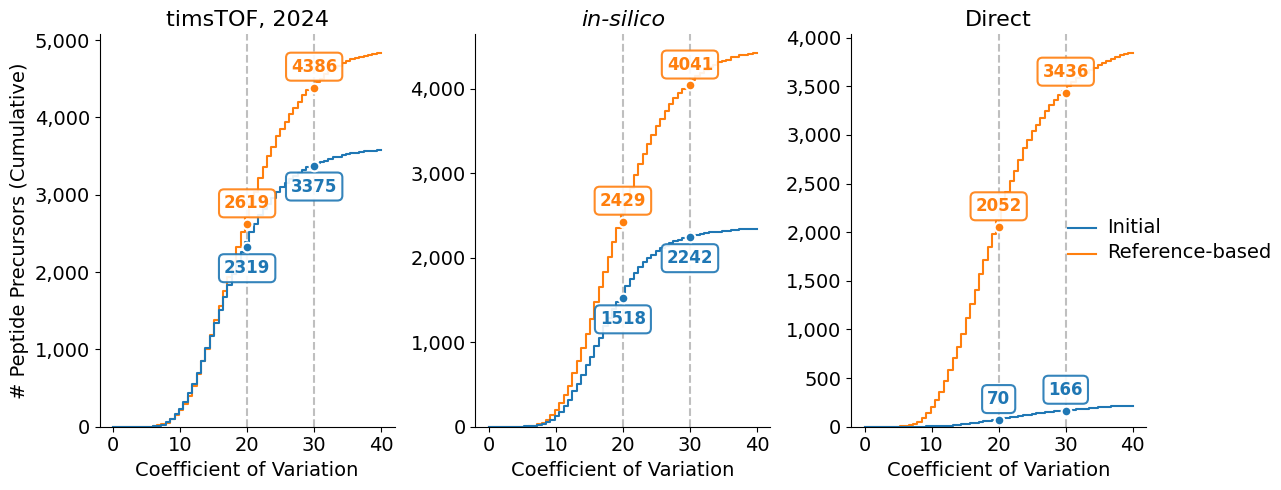

In [8]:
height=4
g = sns.displot(
    data=cvs_df_diann,
    x="cv",
    col="Library",
    hue="Condition",
    hue_order=condition.values(),
    col_wrap=3, stat='count', cumulative=True, element='step', fill=False, binrange=(0, 40),
    facet_kws = dict(sharex=False, sharey=False), aspect=8/3/height
)



# Add vertical lines and labels for each subplot
for lib, ax in g.axes_dict.items():
    ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=30, color='gray', linestyle='--', alpha=0.5)
    
    
    # Get data for this library
    lib_data = cvs_df_diann[cvs_df_diann['Library'] == lib]
    
    # Define colors manually to match seaborn defaults
    colors = {condition['orig']: '#1f77b4', condition['refined']: '#ff7f0e'}  # seaborn default colors
    
    # For each condition, find counts at 10% and 20% CV
    if lib == 'Direct':
        label_offset = {condition['orig']: 15, condition['refined']: 15}  # Different vertical offsets
    else:
        label_offset = {condition['orig']: -15, condition['refined']: 15}  # Different vertical offsets

    
    for i, condition_name in enumerate(condition.values()):
        cond_data = lib_data[lib_data['Condition'] == condition_name]
        
        # Count IDs with CV <= 20% and CV <= 30%
        count_20cv = len(cond_data[cond_data['cv'] <= 20])
        count_30cv = len(cond_data[cond_data['cv'] <= 30])
        
        color = colors.get(condition_name, ['#1f77b4', '#ff7f0e'][i])
        
        # Add points at 10% and 20% CV
        ax.plot(20, count_20cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)
        ax.plot(30, count_30cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)
        
        # Add labels with counts - positioned to avoid overlap
        offset_y = label_offset[condition_name]
        
        ax.annotate(f'{count_20cv}', 
                   xy=(20, count_20cv), 
                   xytext=(0, offset_y), 
                   textcoords='offset points',
                   fontsize=12, 
                   color=color,
                   fontweight='bold',
                   ha='center',
                   va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                           edgecolor=color, alpha=0.9, linewidth=1.5))
        
        ax.annotate(f'{count_30cv}', 
                   xy=(30, count_30cv), 
                   xytext=(0, offset_y), 
                   textcoords='offset points',
                   fontsize=12, 
                   color=color,
                   fontweight='bold',
                   ha='center',
                   va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                           edgecolor=color, alpha=0.9, linewidth=1.5))

# Set better axis labels with larger fonts
g.set_axis_labels(x_var="Coefficient of Variation", y_var='# Peptide Precursors (Cumulative)')

# Adjust titles for each subplot with larger fonts
g.set_titles("{col_name}")

# Make all text larger
for ax in g.axes.flat:
    if ax.get_title() == 'in-silico':
        ax.set_title('in-silico', fontstyle='italic')
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.title.set_size(16)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))


# Make legend text larger
legend = g._legend
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)
    legend.set_title('')  # Remove legend title
    legend.set_bbox_to_anchor((1.1, 0.5))


# Show the plot
plt.tight_layout()
plt.savefig("Figure-S20.png", dpi=600, bbox_inches='tight')

#### **Effect Size Quantification**

In [9]:
def get_quant_rslts(cvs, software):
    quant_rslts = { i:defaultdict(dict) for i in cvs.keys() }
    for lib in cvs.keys():
        for cond in cvs[lib].keys():
            tmp = cvs[lib][cond]
            for cutoff in [20, 30]:
                quant_rslts[lib][cond][cutoff] = len(tmp[tmp['cv'] < cutoff])
        
    
    rows = []
    
    for lib, conditions in quant_rslts.items():
        for cond, depths in conditions.items():
            for depth, value in depths.items():
                rows.append((lib, cond, depth, value))
    
    quant_rslts = pd.DataFrame(rows, columns=["library", "condition", "cv", "ids"])
    quant_rslts['software'] = software
    return quant_rslts

quant_rslts_diann = get_quant_rslts(cvs_diann, 'DIA-NN')


In [10]:
quant_rslts_summary = quant_rslts_diann[['condition', 'cv','ids']].groupby(['cv', 'condition']).mean()
quant_rslts_summary

ids
cv condition                   
20 Initial          1302.333333
   Reference-based  2366.666667
30 Initial          1927.666667
   Reference-based  3954.333333

In [11]:
quant_rslts_summary.loc[(20, 'Reference-based'), 'ids'] - quant_rslts_summary.loc[(20, 'Initial'), 'ids']

np.float64(1064.3333333333333)

In [12]:
quant_rslts_summary.loc[(30, 'Reference-based'), 'ids'] - quant_rslts_summary.loc[(30, 'Initial'), 'ids']

np.float64(2026.6666666666667)